# 1. Tool Calling Agent
Tool Calling Agent는 자신이 가진 지식만 사용하는 것이 아니라, 외부 도구(API, 데이터베이스, 코드 실행기 등)를 호출해 문제를 해결하는 에이전트입니다. 사용자의 질문을 이해한 뒤 필요한 경우 적절한 툴을 선택하고, 입력값을 구성해 호출하며, 반환된 결과를 다시 가공해 최종 답변을 만듭니다. 쉽게 말해, 단순히 대화만 하는 AI가 아니라 “필요할 때 계산기, 검색엔진, 데이터 조회 도구 같은 도구를 직접 쓸 수 있는 AI”가 Tool Calling Agent입니다.

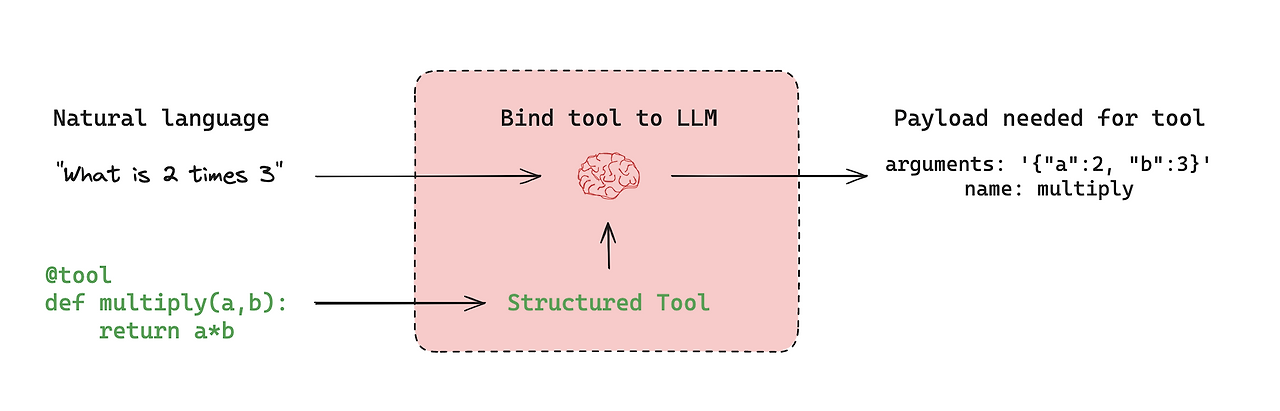

## 2. 웹 검색을 하는 챗봇

### 1. Tavily
Tavily는 웹을 실시간으로 검색해 AI가 최신·정확한 정보를 답변할 수 있도록 돕는 AI용 검색·브라우징 API 플랫폼입니다.
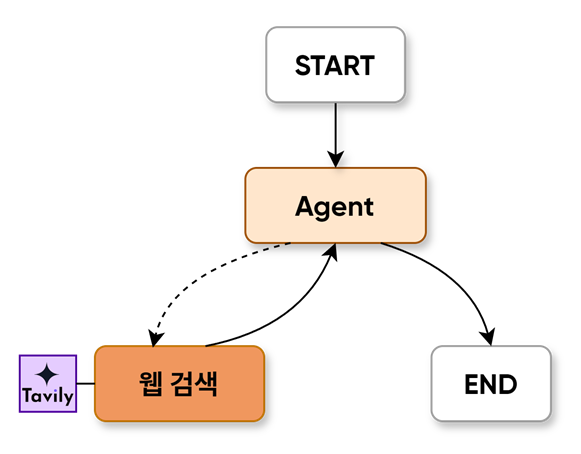

In [ ]:
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

In [ ]:
from tavily import TavilyClient

tavily_client = TavilyClient()

In [ ]:
response = tavily_client.search("What is son hueng-min", max_results = 3) # , topic="news", days = 10

In [ ]:
response['results']
# 이걸 실행하면 tavily가 검색한 결과를 보여줍니다.

In [ ]:
# get_search_context: 보통 문자열(string) 형태이며, 여러 개의 검색 결과에서 중요한 내용만 추려서 한 덩어리의 텍스트로 제공합니다.
context = tavily_client.get_search_context(query="What is AI Agent?")
context

In [ ]:
# qna_search: Tavily가 반환한 최종 답변. 보통 문자열(string) 형태이며, 한두 문장 정도로 정리된 응답을 제공합니다.
answer = tavily_client.qna_search(query="What is AI Agent?")
answer

## 2. TavilySearch

공식문서 : https://python.langchain.com/docs/integrations/tools/tavily_search/

In [ ]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3)
tool.invoke("What's a 'node' in LangGraph?")

In [ ]:
invoke_with_toolcall = tool.invoke({"args": {'query': "What's a 'node' in LangGraph?"}, "type": "tool_call", "id": "foo", "name": "tavily_search"})
invoke_with_toolcall
# args: Tool에 전달될 값
# query: 검색할 내용
# type: 호출이 "tool_call"임을 나타냄(정해져있음)
# id: 호출의 고유 식별자(예시에서는 "foo"로 설정) 
# name: 호출할 도구의 이름(예시에서는 "tavily_search"로 설정)
# .invoke()는 LangChain Tool 호출 형식으로 입력을 받을 수 있습니다.
# 단순 문자열을 넣는 대신, JSON(딕셔너리) 구조로 툴 호출 이벤트(tool call event)처럼 전달하는 방식입니다.

In [ ]:
invoke_with_toolcall.content

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tool.invoke("What's a 'node' in LangGraph?")

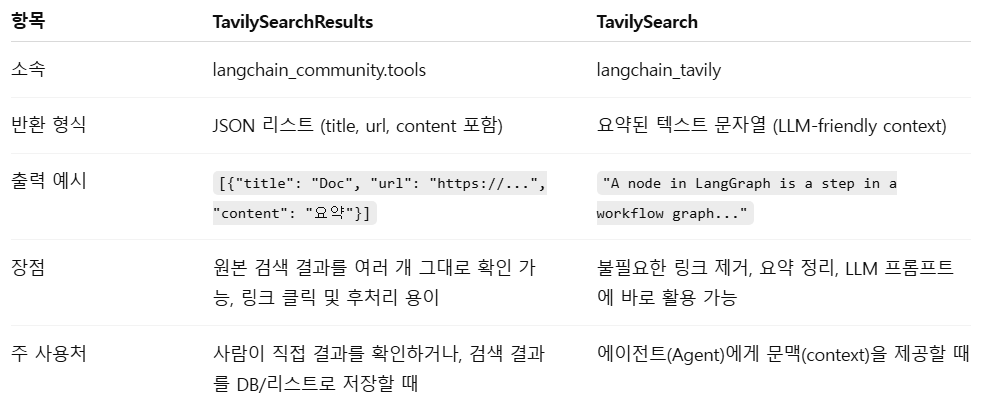

In [ ]:
invoke_with_toolcall = tool.invoke({"args": {'query': "What's a 'node' in LangGraph?"}, "type": "tool_call", "id": "foo", "name": "tavily"})
invoke_with_toolcall

In [ ]:
# results에 들어 있는 정보
invoke_with_toolcall.content

In [ ]:
# 모델의 모든 실행결과
invoke_with_toolcall.artifact

In [ ]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """두 개의 정수를 입력받아 더한 값을 반환합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """두 개의 정수를 입력받아 곱한 값을 반환합니다."""
    return a * b

tools = [add, multiply]

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-nano") # model="gpt-4o"
llm_with_tools = llm.bind_tools(tools)

In [ ]:
query = "What is 3 * 12? Also, what is 11 + 49?"

llm_with_tools.invoke(query).tool_calls

In [ ]:
query = "What is 12 % 2?"

llm_with_tools.invoke(query).tool_calls

In [ ]:
llm_with_tools = llm.bind_tools(tools,
    tool_choice={"type": "function", "function": {"name": "multiply"}}
)

resp = llm_with_tools.invoke("What is 3 * 12? Use tool.")
print(resp.tool_calls)  # 이제 비어있지 않음

In [ ]:
from langchain_openai import ChatOpenAI

tool = TavilySearch(max_results=2)
tools = [tool]

llm = ChatOpenAI(model="gpt-5-nano")
llm_with_tools = llm.bind_tools(tools) # TavilySearch(tools) 을 호출할 수 있도록 함

In [ ]:
llm_with_tools.invoke("안녕")

In [ ]:
llm_with_tools.invoke("What is Langgraph?")

In [ ]:
llm_with_tools.invoke("What is Langgraph?").tool_calls

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]} # 일반적인 질문에 대한 일반 답변 or tool_calls

graph_builder.add_node("chatbot", chatbot)

## 4. ToolNode
ToolNode는 LangGraph에서 도구 호출을 실제로 실행해 주는 노드입니다. LLM이 생성한 AIMessage.tool_calls를 읽어 각 호출의 도구 이름과 인자를 매칭해 실행하고, 결과를 ToolMessage로 반환하여 그래프의 상태(대화 기록)에 추가합니다. 보통 “LLM 노드 → ToolNode → LLM 노드” 형태의 루프에서 사용되며, tools_condition 같은 조건부 엣지와 함께 붙여 LLM이 도구를 요청할 때만 ToolNode가 동작하게 합니다. 요약하면, ToolNode는 LLM의 툴 호출 계획을 실제 코드 실행으로 연결하는 브리지로, 도구 레지스트리(이름→함수/툴)만 넘겨주면 호출·에러 처리·결과 전달까지 표준화된 방식으로 처리해줍니다.

In [ ]:
'''
AIMessage(content='', additional_kwargs={'refusal': None}, 
response_metadata={'token_usage': {'completion_tokens': 282, 
'prompt_tokens': 1273, 'total_tokens': 1555, 'completion_tokens_details': 
{'accepted_prediction_tokens': 0, 
'audio_tokens': 0, 'reasoning_tokens': 256, 
'rejected_prediction_tokens': 0}, 
'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1024}}, 
'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 
'system_fingerprint': None, 
'id': 'chatcmpl-DKiZF02rjYIK61B2mrtN109HSzSUc', 
'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, 
id='lc_run--019d0085-af24-7cc1-8f95-05a41cfd449d-0', 
tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Langgraph'}, 
'id': 'call_UlmoRCol3Njzw3FyzeMvI6uG', 'type': 'tool_call'}], 
invalid_tool_calls=[], usage_metadata={'input_tokens': 1273, 
'output_tokens': 282, 'total_tokens': 1555, 
'input_token_details': {'audio': 0, 'cache_read': 1024}, 
'output_token_details': {'audio': 0, 'reasoning': 256}})
'''

#  답변 본문
#  툴 호출 정보
#  토큰 사용량
#  모델 이름
#  종료 이유
#  기타 메타데이터

# tool_calls = []: 모델이 툴을 호출하려고 시도한 모든 경우가 담겨지는 데이터
#  - name(툴 이름), args, id, type
# invalid_tool_calls = []: 모델이 툴을 호출하려다 형식을 잘못 만든 경우 담겨지는 데이터
#  - name, args, id, type, reason (없으면 호출 성공)
# token_usage: 얼마나 토큰이 사용되었는지에 대한 정보
#  - completion_tokens(입력 토큰), prompt_tokens(출력 토큰), input_tokens, output_tokens, total_tokens


In [ ]:
import json
from langchain_core.messages import ToolMessage
from langgraph.prebuilt import ToolNode

class BasicToolNode:
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools} # ["tavily_search" : TavilySearch()]
        # 여러 툴을 반복하며 툴이 있나 확인, 이름을 리턴시켜 저장장
    def __call__(self, inputs: dict): # 함수처럼 실행
        if messages := inputs.get("messages", []): 
            # 키를 통해 값을 불러오고, 없으면 
            # 빈 리스트 반환 >(:=)를 통해 값을 할당하며 반환(if문 처리)
            message = messages[-1] # 마지막 message
        else:
            raise ValueError("No message found in input")
        
        outputs = []
        for tool_call in message.tool_calls: # 메시지에서 호출된 도구를 불러옴
            tool_result = self.tools_by_name[tool_call["name"]].invoke( # Tool 호출 실행
                tool_call["args"]
            )
            outputs.append( # Tool 호출 결과(ToolMessage) 추가
                ToolMessage(
                    content=json.dumps(tool_result), # Tool 호출 결과를 문자열로 변환하여 content에 저장
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}

tool_node = BasicToolNode(tools=[tool])
# tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

In [ ]:
def route_tools(state: State):
    if isinstance(state, list):
        ai_message = state[-1] # messages의 마지막 요소가 AIMessage라고 가정
    elif message := state.get("messages", []):
        ai_message = message[-1]
    else:
        raise ValueError(f"No message found in state {state}")
    
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_conditional_edges("chatbot", route_tools, {"tools": "tools", END: END}) # chatbot에서 route_tools 함수를 통해 tools 또는 END로 이동하도록 조건부 엣지 추가

In [ ]:
# 엣지 연결
graph_builder.add_edge("tools", "chatbot") # 도구가 호출될 때마다 챗봇으로 돌아가 다음 단계를 결정
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()
graph

In [ ]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}): # graph 노드 호출 결과 받아옴
        for value in event.values():
            print("Assistant:", value["messages"][-1].content) # AI 답변 출력

            #AI답변은 항상 마지막에 출력됨.

In [ ]:
while True:
    try:
        user_input = input("User: ")
        print("User:", user_input)
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

# 5. create_react_agent
create_react_agent는 LangChain에서 ReAct 패턴(Reason+Act)을 따르는 에이전트를 손쉽게 구성하는 팩토리로, LLM과 사용할 도구 목록, 그리고 적절한 프롬프트를 결합해 “생각→도구 호출→관찰→최종 답변”의 반복 루프를 수행하는 Agent 객체를 만들어줍니다. 이 에이전트는 질문을 해석해 필요한 도구를 선택하고 인자를 구성해 호출한 뒤, 결과를 반영해 다음 행동을 결정하며, 보통 AgentExecutor와 함께 실행하여 다단계 추론과 복수의 툴 호출을 자동으로 오케스트레이션합니다. 핵심은 프롬프트(지침), LLM, 툴 레지스트리(이름→함수/API), 출력 파서를 표준화해 붙여주는 것이며, OpenAI 스타일의 툴콜을 포함한 다양한 LLM과 호환되어 실용적인 “생각하며 도구를 쓰는” 에이전트를 빠르게 구성할 수 있게 해주는 점입니다.

In [ ]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

tool = TavilySearch(max_results=2)
tools = [tool]

llm = ChatOpenAI(model="gpt-5.4-2026-03-05")
agent = create_agent(llm, tools)



In [ ]:
response = agent.invoke({"messages": [{"role": "user", "content": "What is LangGraph?"}]})
response

{'messages': [HumanMessage(content='What is LangGraph?', additional_kwargs={}, response_metadata={}, id='8b3b9322-d5e6-4545-bd76-5ed400c80366'),
  AIMessage(content='LangGraph is a framework from the LangChain ecosystem for building **stateful, multi-step AI applications**, especially ones based on **LLM agents and workflows**.\n\nIn simple terms:\n\n- **LangChain** helps you call models, tools, retrievers, etc.\n- **LangGraph** helps you organize those calls as a **graph of steps** with **state** flowing between them.\n\n## Core idea\n\nInstead of writing a linear chain like:\n\n1. get user input\n2. call model\n3. use tool\n4. call model again\n5. return answer\n\nLangGraph lets you define a graph where:\n\n- **nodes** = functions or model/tool steps\n- **edges** = how execution moves between steps\n- **state** = shared data passed and updated across steps\n- **conditions** = routing logic, loops, branching, retries, human approval, etc.\n\nThis makes it good for things like:\n\n- AI agents that decide what tools to use\n- multi-step reasoning workflows\n- human-in-the-loop approval systems\n- long-running workflows\n- applications that need memory, checkpoints, or resumability\n\n## Why it exists\n\nBasic chains are fine for simple flows, but real agent systems often need:\n\n- loops\n- branching\n- retries\n- persistence\n- interruption and resume\n- multiple cooperating agents\n\nLangGraph is designed for that kind of control.\n\n## Example mental model\n\nImagine a customer support agent:\n\n- Node A: classify the issue\n- Node B: search documentation\n- Node C: draft an answer\n- Node D: ask a human for approval if confidence is low\n- Node E: send final response\n\nThe graph controls when to go from one node to another, and the state tracks things like:\n\n- user question\n- retrieved docs\n- draft response\n- confidence score\n- approval status\n\n## What makes LangGraph notable\n\nCommon features/concepts include:\n\n- **Graph-based orchestration**\n- **Persistent state**\n- **Checkpointing**\n- **Streaming**\n- **Human-in-the-loop interrupts**\n- **Agent workflows**\n- **Cycles/loops**, unlike many simple DAG-style orchestrators\n\n## Tiny conceptual example\n\nYou might define:\n\n- a shared state object:\n  - `messages`\n  - `tool_results`\n  - `next_step`\n\nThen create nodes like:\n\n- `agent`\n- `tool_executor`\n- `finalizer`\n\nAnd edges such as:\n\n- start → agent\n- if tool needed → tool_executor\n- tool_executor → agent\n- if done → finalizer\n\nThat loop is a common agent pattern.\n\n## In one sentence\n\n**LangGraph is a framework for building controllable, stateful LLM workflows and agents using graph-based execution.**\n\nIf you want, I can also give you:\n\n1. a **simple Python example**,  \n2. a **LangGraph vs LangChain** comparison, or  \n3. a **real-world agent architecture diagram in words**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 606, 'prompt_tokens': 1273, 'total_tokens': 1879, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DKjdRifrkBSLGx4YxmIavkhGJKhV1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d00c4-4f5a-7d20-ba42-6eb90535a02e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1273, 'output_tokens': 606, 'total_tokens': 1879, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [ ]:
from pydantic import BaseModel, Field

In [ ]:
class MovieResponse(BaseModel):
    title: str = Field(..., description="The title of the movie")
    director: str = Field(..., description="The director of the movie")
    genre: str = Field(..., description="The genre of the movie")
    release_year: int = Field(..., description="The release year of the movie")


In [ ]:
model = ChatOpenAI(model="gpt-5.4-2026-03-05")
model_with_structured_output = model.with_structured_output(MovieResponse)
model_with_structured_output.invoke("메멘토 영화 설명해줘")

In [ ]:
from typing import Union
class MovieResponse(BaseModel):
    title: str = Field(description="영화 제목")
    director: str = Field(description="감독 이름")
    genre: str = Field(description="장르")
    release_year: int = Field(description="개봉 연도")

class ConversationalResponse(BaseModel):
    response: str = Field(description='사용자에게 친구처럼 건방지게 답하는 문장')

class FinalResponse(BaseModel):
    final_output: Union[MovieResponse, ConversationalResponse]

In [ ]:
structured_llm = model.with_structured_output(FinalResponse)
structured_llm.invoke('메멘토 영화에 대해 설명해봐')

In [ ]:
structured_llm.invoke('오늘 야식은 뭐 먹지?')

In [ ]:
from langgraph.graph import MessagesState
from typing import Literal
from langchain_core.tools import tool

In [ ]:
#HumanMessage(..), AIMessage(..), ToolMessage(..) 
class State(MessagesState):
    final_output: MovieResponse

In [ ]:
@tool
def get_movie_info(movie: Literal['위플래쉬', '인터스텔라']):
    '''아래 설명은 영화에 대한 내용이다 참고해'''
    if movie == '위플래쉬':
        return "영화 **<위플래쉬>(Whiplash)**는 최고의 드러머가 되려는 연습생과 그를 한계까지 몰아붙이는 폭군 선생 사이의 광기 어린 대립을 그린 음악 영화입니다."
    elif movie == '인터스텔라':
        return "인터스텔라는 인류의 미래를 구하기 위해 우주로 떠난 탐사대가 사랑과 시간, 과학의 한계를 넘어서며 펼치는 감동적인 SF 영화입니다."
    else:
        raise AssertionError("지원하지 않는 영화입니다.")


In [ ]:
tools = [get_movie_info]
model_with_tool= model.bind_tools(tools)

In [ ]:
def call_model(state: State):
    response = model_with_tool.invoke(state.messages) # state의 messages를 모델에 전달하여 응답을 받음
    return {"messages": [response]}

In [ ]:
from langchain_core.messages import HumanMessage

In [ ]:
model= ChatOpenAI(model="gpt-5.4-2026-03-05")
model_with_structured_output = model.with_structured_output(MovieResponse)

In [ ]:
def respond(state: State):
    response = model_with_structured_output.invoke(
        [HumanMessage(content = state['messages'][-2].content)]
    )
    return {"final_response": [response]}


In [ ]:
def should_continue(state: State):
    messages = state['messages']
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "respond"
    return "continue"

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode


In [ ]:

graph_builder = StateGraph(State)
graph_builder.add_node("agent", call_model)
graph_builder.add_node("respond", respond)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.set_entry_point("agent")
graph_builder.add_conditional_edges("agent", should_continue, {"respond": "respond", "continue": "tools"})
graph_builder.add_edge("tools", "agent") # 도구가 호출될 때마다 챗봇으로 돌아가 다음 단계를 결정
graph = graph_builder.compile()

In [ ]:
graph